In [1]:
import matplotlib.pyplot as plt
import pandas as pd

## Donut Charts - RQ2.2 Analysis

Creating single combined nested donut for RQ2.2...


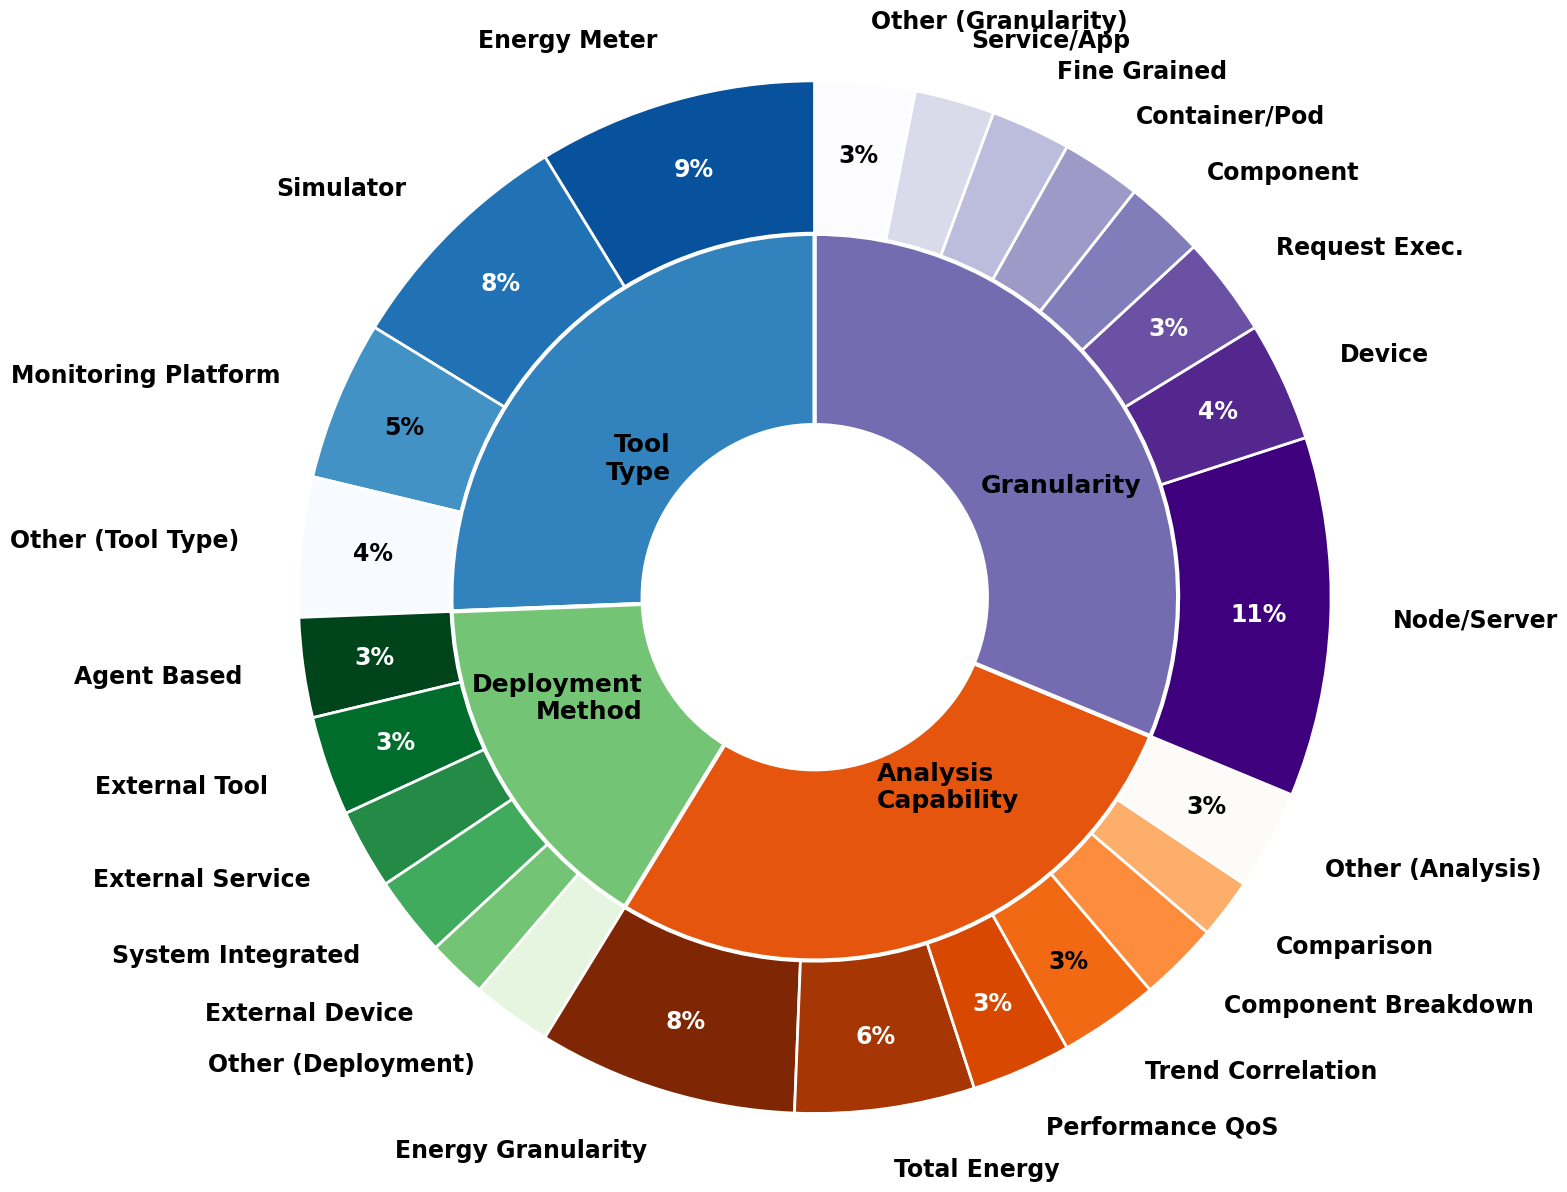

✓ Combined nested donut saved to: output/rq2.2_nested_combined.pdf

=== Summary ===

Single Nested Donut - Combined Characteristics:
  Tool Type: 41 tools
  Deployment Method: 25 classifications
  Analysis Capability: 44 classifications
  Granularity: 50 classifications

✓ Items with count ≤ 2 are grouped into per-dimension 'Other' categories

LLM_CONTEXT_INNER_BEGIN
dimension|count|percent_total
Tool Type|41|25.62%
Deployment Method|25|15.62%
Analysis Capability|44|27.50%
Granularity|50|31.25%
LLM_CONTEXT_INNER_END

LLM_CONTEXT_OUTER_BEGIN
dimension|label|count|percent_total|percent_of_dimension
Tool Type|Energy Meter|14|8.75%|34.15%
Tool Type|Simulator|12|7.50%|29.27%
Tool Type|Monitoring Platform|8|5.00%|19.51%
Tool Type|Other (Tool Type)|7|4.38%|17.07%
Deployment Method|Agent Based|5|3.12%|20.00%
Deployment Method|External Tool|5|3.12%|20.00%
Deployment Method|External Service|4|2.50%|16.00%
Deployment Method|System Integrated|4|2.50%|16.00%
Deployment Method|External Device|3|1.88

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Create output directory if it doesn't exist
output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)

print("Creating single combined nested donut for RQ2.2...")

# Inner ring: four high-level dimensions
inner_labels = ['Tool\nType', 'Deployment\nMethod', 'Analysis\nCapability', 'Granularity']
inner_sizes = [41, 25, 44, 50]
inner_colors = ['#3182bd', '#74c476', '#e6550d', '#756bb1']

# Base data for outer ring
tool_type_labels = [
    'Energy Meter', 'Simulator', 'Monitoring Platform', 'Benchmark Gen.',
    'Energy Est. Tool', 'Framework', 'Model Checker', 'OS API'
]
tool_type_sizes = [14, 12, 8, 2, 2, 1, 1, 1]
tool_type_palette = ['#08519c', '#2171b5', '#4292c6', '#6baed6', '#9ecae1', '#c6dbef', '#deebf7', '#f7fbff']

deployment_labels = [
    'Agent Based', 'External Tool', 'External Service', 'System Integrated',
    'External Device', 'Local App', 'Container Orch.', 'Remote API'
]
deployment_sizes = [5, 5, 4, 4, 3, 2, 1, 1]
deployment_palette = ['#00441b', '#006d2c', '#238b45', '#41ab5d', '#74c476', '#a1d99b', '#c7e9c0', '#e5f5e0']

analysis_labels = [
    'Energy Granularity', 'Total Energy', 'Performance QoS', 'Trend Correlation',
    'Component Breakdown', 'Comparison', 'Sustainability', 'Pattern Detect.',
    'Security Metrics', 'Validation Ver.'
]
analysis_sizes = [13, 9, 5, 5, 4, 3, 2, 1, 1, 1]
analysis_palette = ['#7f2704', '#a63603', '#d94801', '#f16913', '#fd8d3c', '#fdae6b', '#fdd0a2', '#fee6ce', '#fff5eb', '#fcfbf7']

granularity_labels = [
    'Node/Server', 'Device', 'Request Exec.', 'Component',
    'Container/Pod', 'Fine Grained', 'Service/App', 'Data Center',
    'Function', 'Network'
]
granularity_sizes = [18, 6, 5, 4, 4, 4, 4, 2, 2, 1]
granularity_palette = ['#3f007d', '#54278f', '#6a51a3', '#807dba', '#9e9ac8', '#bcbddc', '#dadaeb', '#e7e1ef', '#f2f0f7', '#fcfbfd']


def collapse_small_items(labels, sizes, palette, threshold, other_label):
    kept_labels = []
    kept_sizes = []
    kept_colors = []
    other_total = 0

    for label, size, color in zip(labels, sizes, palette):
        if size <= threshold:
            other_total += size
        else:
            kept_labels.append(label)
            kept_sizes.append(size)
            kept_colors.append(color)

    if other_total > 0:
        kept_labels.append(other_label)
        kept_sizes.append(other_total)
        kept_colors.append(palette[-1])

    return kept_labels, kept_sizes, kept_colors


threshold = 2

tool_labels_c, tool_sizes_c, tool_colors_c = collapse_small_items(
    tool_type_labels, tool_type_sizes, tool_type_palette, threshold, 'Other (Tool Type)'
)
deploy_labels_c, deploy_sizes_c, deploy_colors_c = collapse_small_items(
    deployment_labels, deployment_sizes, deployment_palette, threshold, 'Other (Deployment)'
)
analysis_labels_c, analysis_sizes_c, analysis_colors_c = collapse_small_items(
    analysis_labels, analysis_sizes, analysis_palette, threshold, 'Other (Analysis)'
)
gran_labels_c, gran_sizes_c, gran_colors_c = collapse_small_items(
    granularity_labels, granularity_sizes, granularity_palette, threshold, 'Other (Granularity)'
)

grouped_data = [
    ('Tool Type', tool_labels_c, tool_sizes_c, tool_colors_c),
    ('Deployment Method', deploy_labels_c, deploy_sizes_c, deploy_colors_c),
    ('Analysis Capability', analysis_labels_c, analysis_sizes_c, analysis_colors_c),
    ('Granularity', gran_labels_c, gran_sizes_c, gran_colors_c),
]

# Outer ring: collapsed subcategories grouped in the same order as inner ring
outer_labels = [label for _, labels, _, _ in grouped_data for label in labels]
outer_sizes = [size for _, _, sizes, _ in grouped_data for size in sizes]
outer_colors = [color for _, _, _, colors in grouped_data for color in colors]


def pct_if_large(pct):
    return f'{pct:.0f}%' if pct >= 3 else ''


def is_dark_color(rgba, threshold=0.5):
    r, g, b, _ = rgba
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return luminance < threshold


fig, ax = plt.subplots(figsize=(14, 12))

# Outer ring: all subcategories
wedges_outer, _, autotexts_outer = ax.pie(
    outer_sizes,
    labels=outer_labels,
    autopct=pct_if_large,
    radius=1.35,
    colors=outer_colors,
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 17, 'fontweight': 'bold'},
    pctdistance=0.86,
    labeldistance=1.12,
    startangle=90
)

# Make percentage text white on dark wedges, black otherwise
for wedge, autotext in zip(wedges_outer, autotexts_outer):
    if autotext.get_text().strip():
        autotext.set_color('white' if is_dark_color(wedge.get_facecolor()) else 'black')
        autotext.set_fontweight('bold')

# Inner ring: high-level dimensions
ax.pie(
    inner_sizes,
    labels=inner_labels,
    radius=0.95,
    colors=inner_colors,
    wedgeprops={'width': 0.5, 'edgecolor': 'white', 'linewidth': 3},
    textprops={'fontsize': 18, 'fontweight': 'bold'},
    labeldistance=0.55,
    startangle=90
)

ax.axis('equal')
plt.tight_layout()

combined_path = os.path.join(output_dir, 'rq2.2_nested_combined.pdf')
fig.savefig(combined_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f"✓ Combined nested donut saved to: {combined_path}")
print("\n=== Summary ===\n")
print("Single Nested Donut - Combined Characteristics:")
print(f"  Tool Type: {inner_sizes[0]} tools")
print(f"  Deployment Method: {inner_sizes[1]} classifications")
print(f"  Analysis Capability: {inner_sizes[2]} classifications")
print(f"  Granularity: {inner_sizes[3]} classifications")
print(f"\n✓ Items with count ≤ {threshold} are grouped into per-dimension 'Other' categories")

# LLM-friendly context output for each datapoint in the chart
total_outer = sum(outer_sizes)
total_inner = sum(inner_sizes)

print("\nLLM_CONTEXT_INNER_BEGIN")
print("dimension|count|percent_total")
for dim_label, dim_count in zip(inner_labels, inner_sizes):
    clean_label = dim_label.replace('\n', ' ')
    pct_total = (dim_count / total_inner * 100) if total_inner else 0
    print(f"{clean_label}|{dim_count}|{pct_total:.2f}%")
print("LLM_CONTEXT_INNER_END")

print("\nLLM_CONTEXT_OUTER_BEGIN")
print("dimension|label|count|percent_total|percent_of_dimension")
for dimension, labels, sizes, _ in grouped_data:
    dimension_total = sum(sizes)
    for label, count in zip(labels, sizes):
        pct_total = (count / total_outer * 100) if total_outer else 0
        pct_dimension = (count / dimension_total * 100) if dimension_total else 0
        print(f"{dimension}|{label}|{count}|{pct_total:.2f}%|{pct_dimension:.2f}%")
print("LLM_CONTEXT_OUTER_END")